In [4]:
import os
os.chdir(r'E:\University\R-Subjects\Artificial Intelligence\New folder\HeartProj\HeartProj')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/data_5000.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass balance:")
print(df['HeartDisease'].value_counts())

Shape: (5000, 17)

First 5 rows:
   Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0   63    1      139.0        217.0          1    128               1   
1   55    1      110.0        214.0          1    180               0   
2   59    0      130.0        338.0          1    130               1   
3   47    1      160.0        237.0          0    124               1   
4   50    1      145.0        237.0          1    139               1   

   Oldpeak  ST_Slope  ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  \
0      1.2         1              False               True              False   
1      0.4         2              False               True              False   
2      1.5         1               True              False              False   
3      0.0         1               True              False              False   
4      0.7         1               True              False              False   

   ChestPainType_TA  RestingECG_LVH  Rest

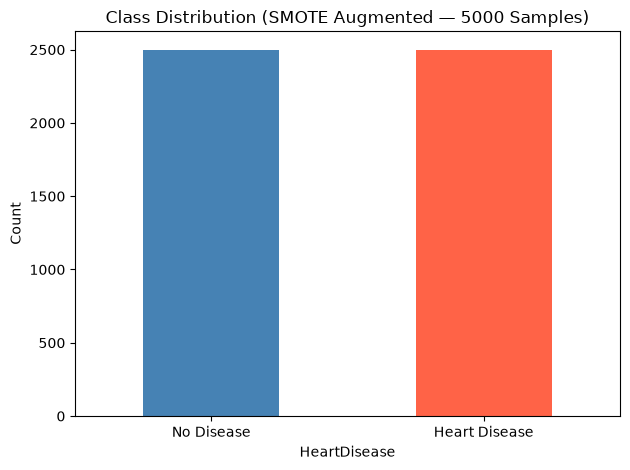

In [5]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Class Distribution (SMOTE Augmented — 5000 Samples)')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

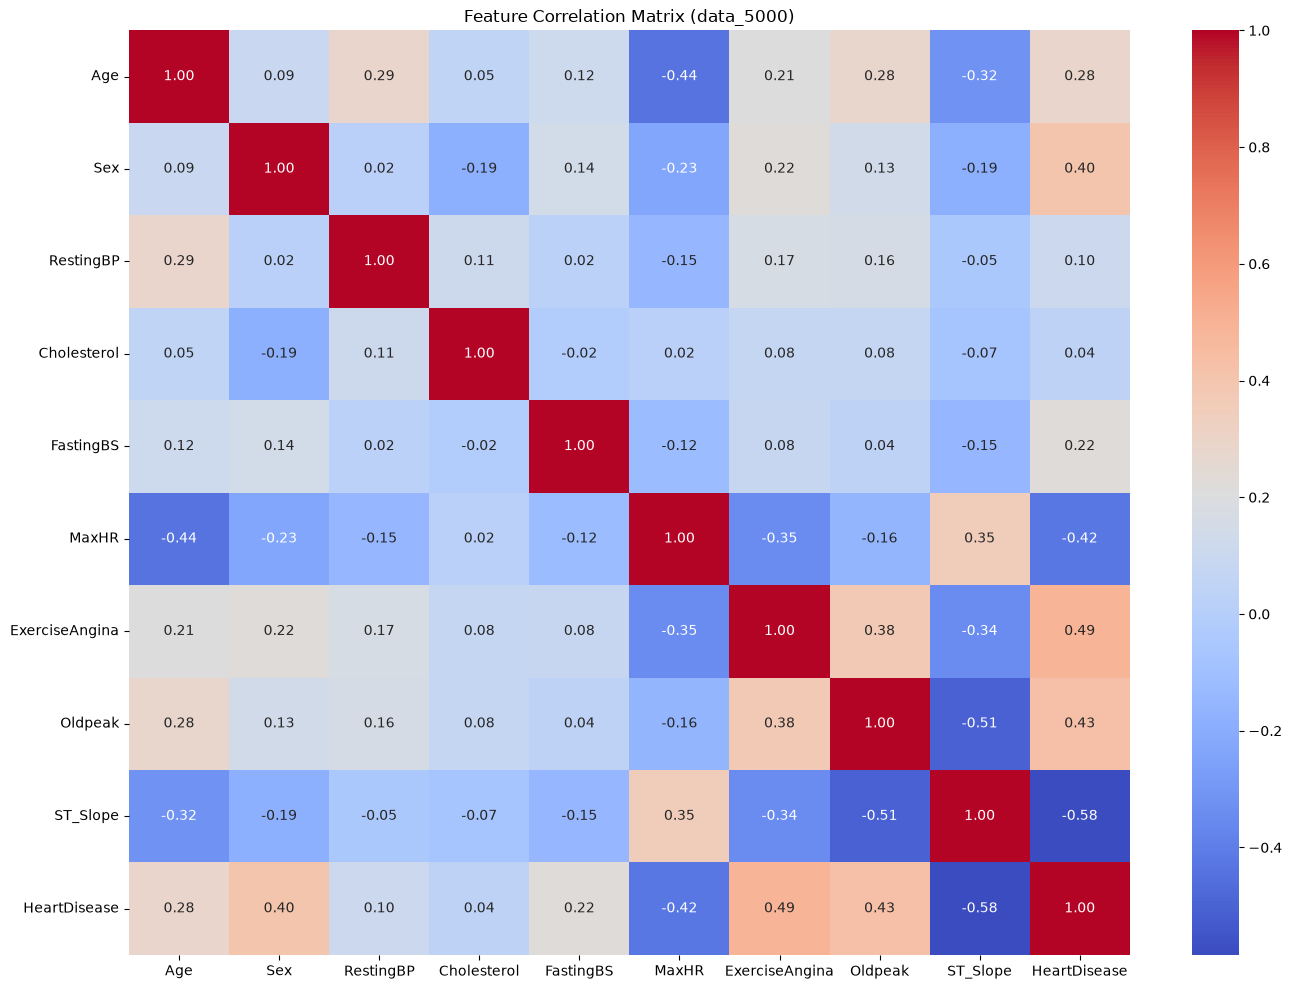

In [6]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix (data_5000)')
plt.tight_layout()
plt.show()

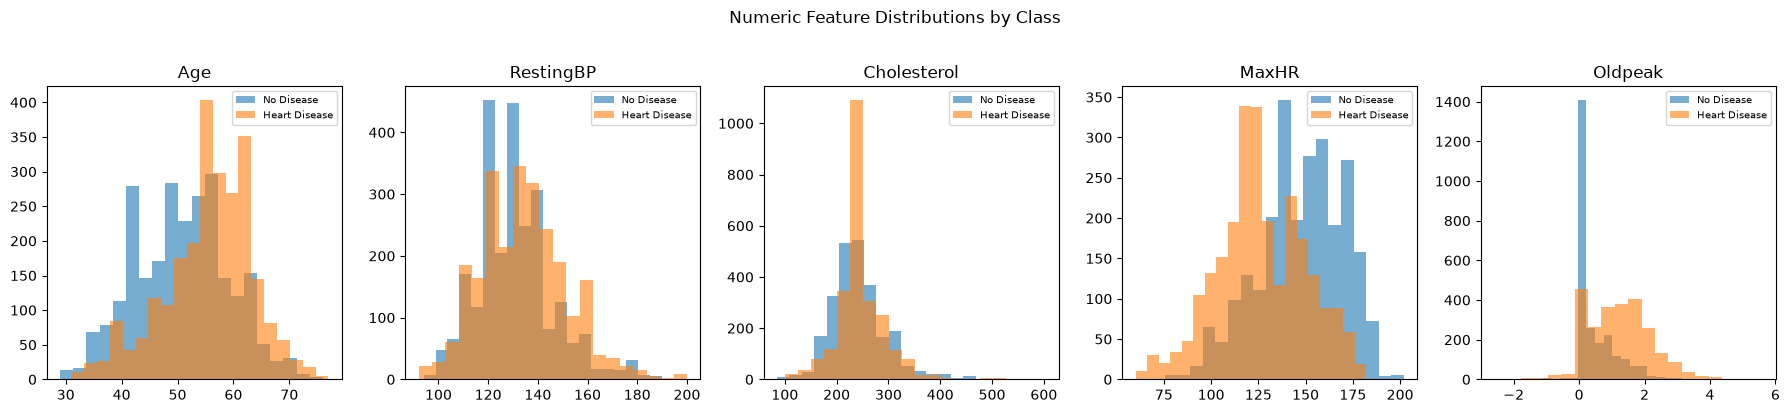

In [7]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_features):
    for label, grp in df.groupby('HeartDisease'):
        ax.hist(grp[col], alpha=0.6, label='Heart Disease' if label == 1 else 'No Disease', bins=20)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle('Numeric Feature Distributions by Class', y=1.02)
plt.tight_layout()
plt.show()

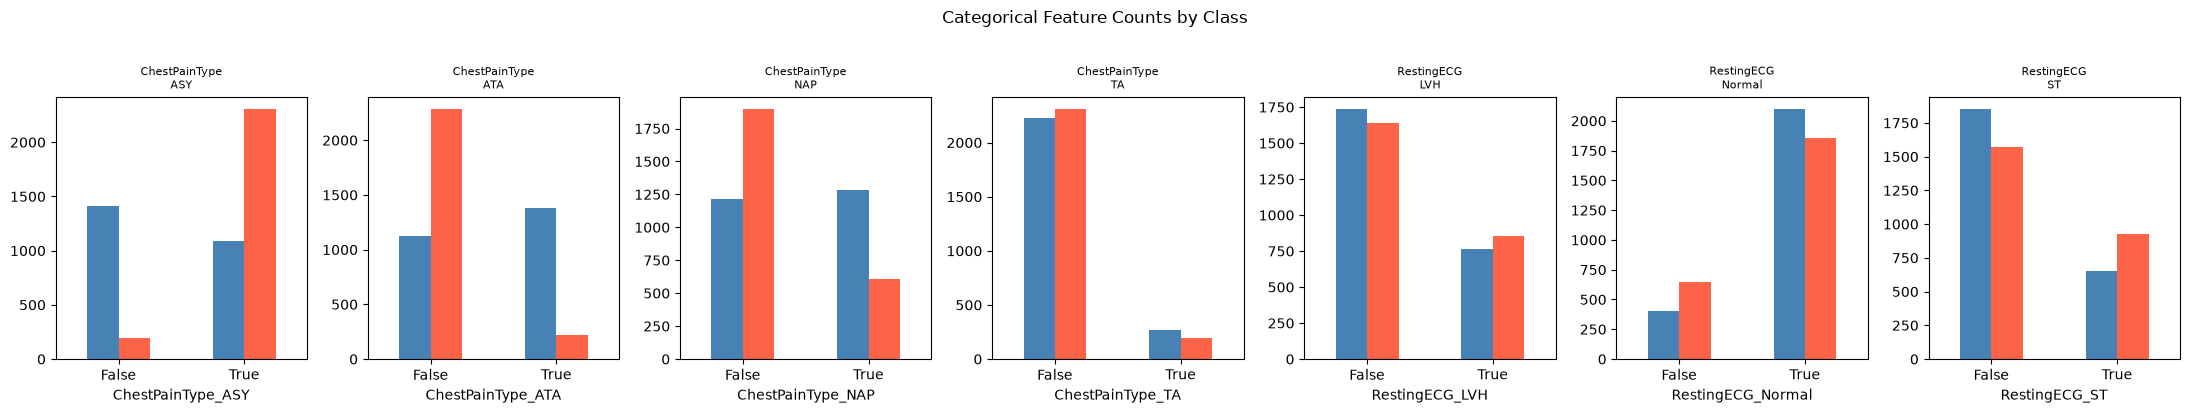

In [8]:
cat_features = ['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
                'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST']

fig, axes = plt.subplots(1, 7, figsize=(22, 4))
for ax, col in zip(axes, cat_features):
    counts = df.groupby(['HeartDisease', col]).size().unstack(fill_value=0)
    counts.T.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], legend=False)
    ax.set_title(col.replace('_', '\n'), fontsize=8)
    ax.set_xticklabels(['False', 'True'], rotation=0)
plt.suptitle('Categorical Feature Counts by Class', y=1.02)
plt.tight_layout()
plt.show()

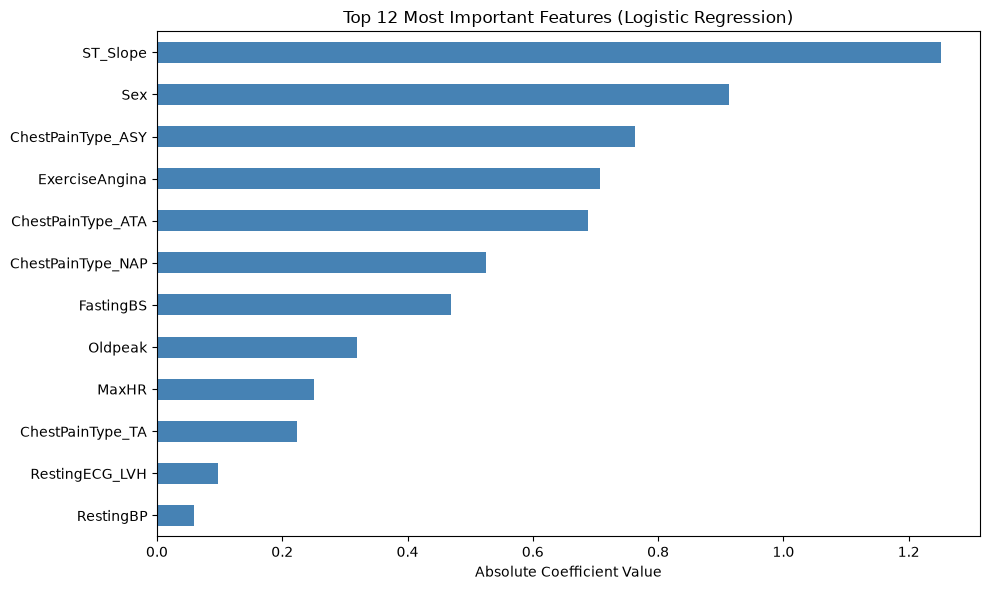

In [9]:
import joblib
import sys
sys.path.append(r'E:\University\R-Subjects\Artificial Intelligence\New folder\HeartProj\HeartProj')
from src.preprocess import load_and_preprocess

X_train, X_test, y_train, y_test, scaler, feature_names = \
    load_and_preprocess('data/data_5000.csv', apply_smote=False)

lr_model = joblib.load('models/logistic_regression.pkl')

coef = lr_model.coef_[0]
importance = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(12).plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 12 Most Important Features (Logistic Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


 Logistic Regression
               precision    recall  f1-score   support

   No Disease       0.88      0.87      0.88       500
Heart Disease       0.87      0.88      0.88       500

     accuracy                           0.88      1000
    macro avg       0.88      0.88      0.88      1000
 weighted avg       0.88      0.88      0.88      1000

ROC-AUC: 0.9474
Accuracy: 0.8760


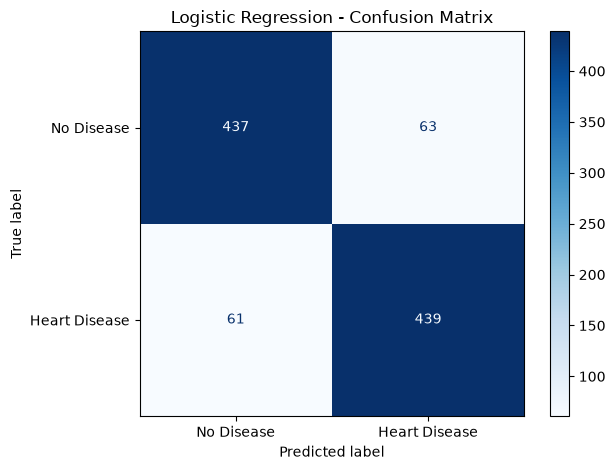

Optimal threshold:     0.248
Precision at optimal:  0.822
Recall at optimal:     0.950
F1 at optimal:         0.881


In [10]:
from sklearn.metrics import precision_recall_curve
from src.evaluate import evaluate_model

lr_proba, _ = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

precisions, recalls, thresholds = precision_recall_curve(y_test, lr_proba)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]

print(f'Optimal threshold:     {best_thresh:.3f}')
print(f'Precision at optimal:  {precisions[best_idx]:.3f}')
print(f'Recall at optimal:     {recalls[best_idx]:.3f}')
print(f'F1 at optimal:         {f1s[best_idx]:.3f}')

In [11]:
df2 = pd.read_csv('data/data_5000.csv')

df2['MaxHR_Age_Ratio']  = df2['MaxHR'] / df2['Age']
df2['High_Cholesterol'] = (df2['Cholesterol'] > 240).astype(int)
df2['Hypertension']     = (df2['RestingBP'] > 140).astype(int)

print('New features added:')
print(df2[['MaxHR_Age_Ratio', 'High_Cholesterol', 'Hypertension']].head(10))
print(f'\nHigh Cholesterol patients: {df2["High_Cholesterol"].sum()}')
print(f'Hypertension patients:     {df2["Hypertension"].sum()}')

New features added:
   MaxHR_Age_Ratio  High_Cholesterol  Hypertension
0         2.031746                 0             0
1         3.272727                 0             0
2         2.203390                 1             0
3         2.638298                 0             1
4         2.780000                 0             1
5         3.306122                 1             0
6         1.906250                 0             1
7         2.872340                 1             0
8         2.846154                 0             0
9         4.365854                 1             0

High Cholesterol patients: 2008
Hypertension patients:     1335


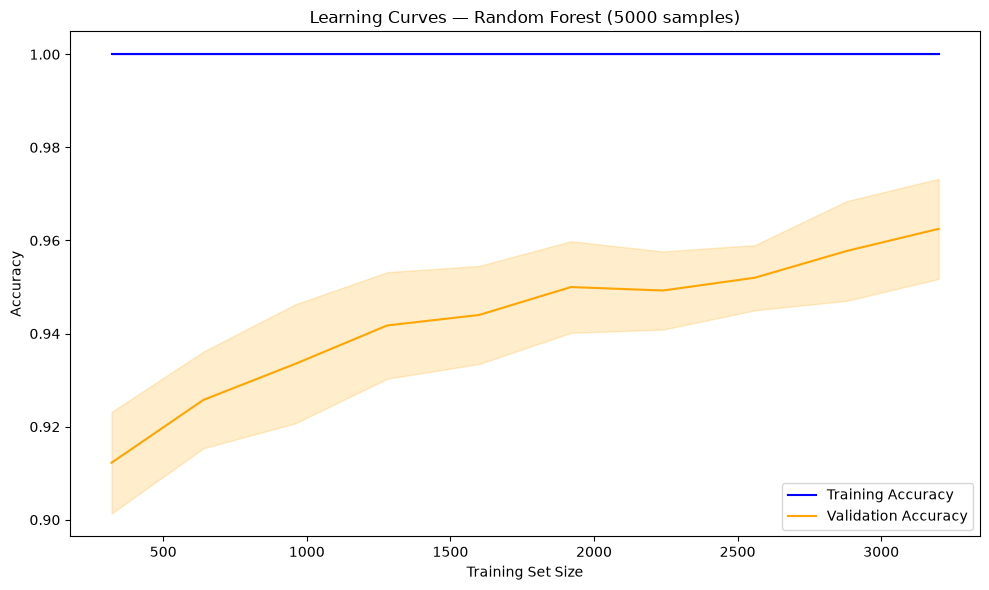

In [12]:
from sklearn.model_selection import learning_curve

rf_model = joblib.load('models/rf_balanced.pkl')

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Accuracy', color='blue')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='blue')
plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Accuracy', color='orange')
plt.fill_between(train_sizes,
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.2, color='orange')
plt.title('Learning Curves — Random Forest (5000 samples)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': joblib.load('models/logistic_regression.pkl'),
    'SVM':                 joblib.load('models/svm_balanced.pkl'),
    'Random Forest':       rf_model
}

print('── Bias-Variance Analysis ──\n')
for name, model in models.items():
    train_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    test_scores  = cross_val_score(model, X_test,  y_test,  cv=5,  scoring='accuracy')
    print(f'{name}:')
    print(f'  Train Accuracy: {train_scores.mean():.4f}')
    print(f'  Bias (error):   {1 - train_scores.mean():.4f}')
    print(f'  Variance:       {train_scores.std():.4f}\n')

── Bias-Variance Analysis ──

Logistic Regression:
  Train Accuracy: 0.8892
  Bias (error):   0.1108
  Variance:       0.0226

SVM:
  Train Accuracy: 0.9447
  Bias (error):   0.0553
  Variance:       0.0140

Random Forest:
  Train Accuracy: 0.9643
  Bias (error):   0.0357
  Variance:       0.0132



In [14]:
import optuna
from sklearn.ensemble import RandomForestClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5)
    }
    model = RandomForestClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f'Best F1 Score:   {study.best_value:.4f}')
print(f'Best Parameters: {study.best_params}')

Best F1 Score:   0.9626
Best Parameters: {'n_estimators': 339, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 1}


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# Train with best Optuna parameters
best_params = study.best_params  # uses the params from above cell directly

rf_optuna = RandomForestClassifier(**best_params, random_state=42)
rf_optuna.fit(X_train, y_train)

# Evaluate
y_pred = rf_optuna.predict(X_test)
y_proba = rf_optuna.predict_proba(X_test)[:, 1]

print('── Optuna Random Forest ──')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

# Save
joblib.dump(rf_optuna, r'E:\University\R-Subjects\Artificial Intelligence\New folder\HeartProj\HeartProj\models\random_forest_optuna.pkl')
print('Optuna model saved')

── Optuna Random Forest ──
               precision    recall  f1-score   support

   No Disease       0.96      0.97      0.96       500
Heart Disease       0.97      0.96      0.96       500

     accuracy                           0.96      1000
    macro avg       0.96      0.96      0.96      1000
 weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9940
Optuna model saved


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

baseline_majority   = [1] * len(y_test)
baseline_acc        = accuracy_score(y_test, baseline_majority)
baseline_f1         = f1_score(y_test, baseline_majority)

np.random.seed(42)
baseline_random     = np.random.choice([0, 1], size=len(y_test), p=[0.5, 0.5])
baseline_random_acc = accuracy_score(y_test, baseline_random)

best_model  = joblib.load('models/xgb_balanced.pkl')
best_acc    = accuracy_score(y_test, best_model.predict(X_test))
best_f1     = f1_score(y_test, best_model.predict(X_test))

print('── Baseline Comparison ──\n')
print(f'Baseline 1 (predict all heart disease):')
print(f'  Accuracy: {baseline_acc:.4f}  |  F1: {baseline_f1:.4f}')
print(f'\nBaseline 2 (random prediction):')
print(f'  Accuracy: {baseline_random_acc:.4f}')
print(f'\nOur Best Model (XGBoost):')
print(f'  Accuracy: {best_acc:.4f}  |  F1: {best_f1:.4f}')
print(f'\nImprovement over baseline: {best_acc - baseline_acc:.4f} ({((best_acc - baseline_acc)/baseline_acc)*100:.1f}%)')

── Baseline Comparison ──

Baseline 1 (predict all heart disease):
  Accuracy: 0.5000  |  F1: 0.6667

Baseline 2 (random prediction):
  Accuracy: 0.5230

Our Best Model (XGBoost):
  Accuracy: 0.9720  |  F1: 0.9721

Improvement over baseline: 0.4720 (94.4%)


In [ ]:
from sklearn.model_selection import train_test_split as tts

rf_optuna = joblib.load('models/random_forest_optuna.pkl')

y_pred  = rf_optuna.predict(X_test)
y_proba = rf_optuna.predict_proba(X_test)[:, 1]

df_orig = pd.read_csv('data/data_5000.csv')
_, df_test_raw = tts(df_orig, test_size=1000, random_state=42, stratify=df_orig['HeartDisease'])
df_test_raw = df_test_raw.reset_index(drop=True)

df_test_raw['Actual']    = y_test.values
df_test_raw['Predicted'] = y_pred
df_test_raw['Correct']   = (df_test_raw['Actual'] == df_test_raw['Predicted']).astype(int)

print('── Error Analysis by Slice ──\n')

print('By Sex (0=Female, 1=Male):')
print(df_test_raw.groupby('Sex')['Correct'].agg(['mean', 'count'])
      .rename(columns={'mean': 'Accuracy', 'count': 'Patients'}))

df_test_raw['AgeGroup'] = pd.cut(df_test_raw['Age'], bins=[20, 40, 50, 60, 80],
                                  labels=['20-40', '40-50', '50-60', '60+'])
print('\nBy Age Group:')
print(df_test_raw.groupby('AgeGroup', observed=True)['Correct'].agg(['mean', 'count'])
      .rename(columns={'mean': 'Accuracy', 'count': 'Patients'}))

print('\nBy ST_Slope (0=Down, 1=Flat, 2=Up):')
print(df_test_raw.groupby('ST_Slope')['Correct'].agg(['mean', 'count'])
      .rename(columns={'mean': 'Accuracy', 'count': 'Patients'}))

── Error Analysis by Slice ──

By Sex (0=Female, 1=Male):
     Accuracy  Patients
Sex                    
0    0.955026       378
1    0.954984       622

By Age Group:
          Accuracy  Patients
AgeGroup                    
20-40     0.989691        97
40-50     0.961390       259
50-60     0.951327       452
60+       0.937500       192

By ST_Slope (0=Down, 1=Flat, 2=Up):
          Accuracy  Patients
ST_Slope                    
0         0.965517        87
1         0.949123       570
2         0.962099       343


In [ ]:
import joblib

mlp = joblib.load(r'E:\University\R-Subjects\Artificial Intelligence\New folder\HeartProj\HeartProj\models\mlp.pkl')

print(f'Best MLP params: {mlp.get_params()}')
print(f'Number of iterations: {mlp.n_iter_}')
print(f'Number of layers: {mlp.n_layers_}')
print(f'Hidden layer sizes: {mlp.hidden_layer_sizes}')
print(f'Activation function: {mlp.activation}')
print(f'Final loss: {mlp.loss_:.6f}')
print(f'Number of outputs: {mlp.n_outputs_}')

Best MLP params: {'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (128,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 500, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Number of iterations: 438
Number of layers: 3
Hidden layer sizes: (128,)
Activation function: tanh
Final loss: 0.006809
Number of outputs: 1


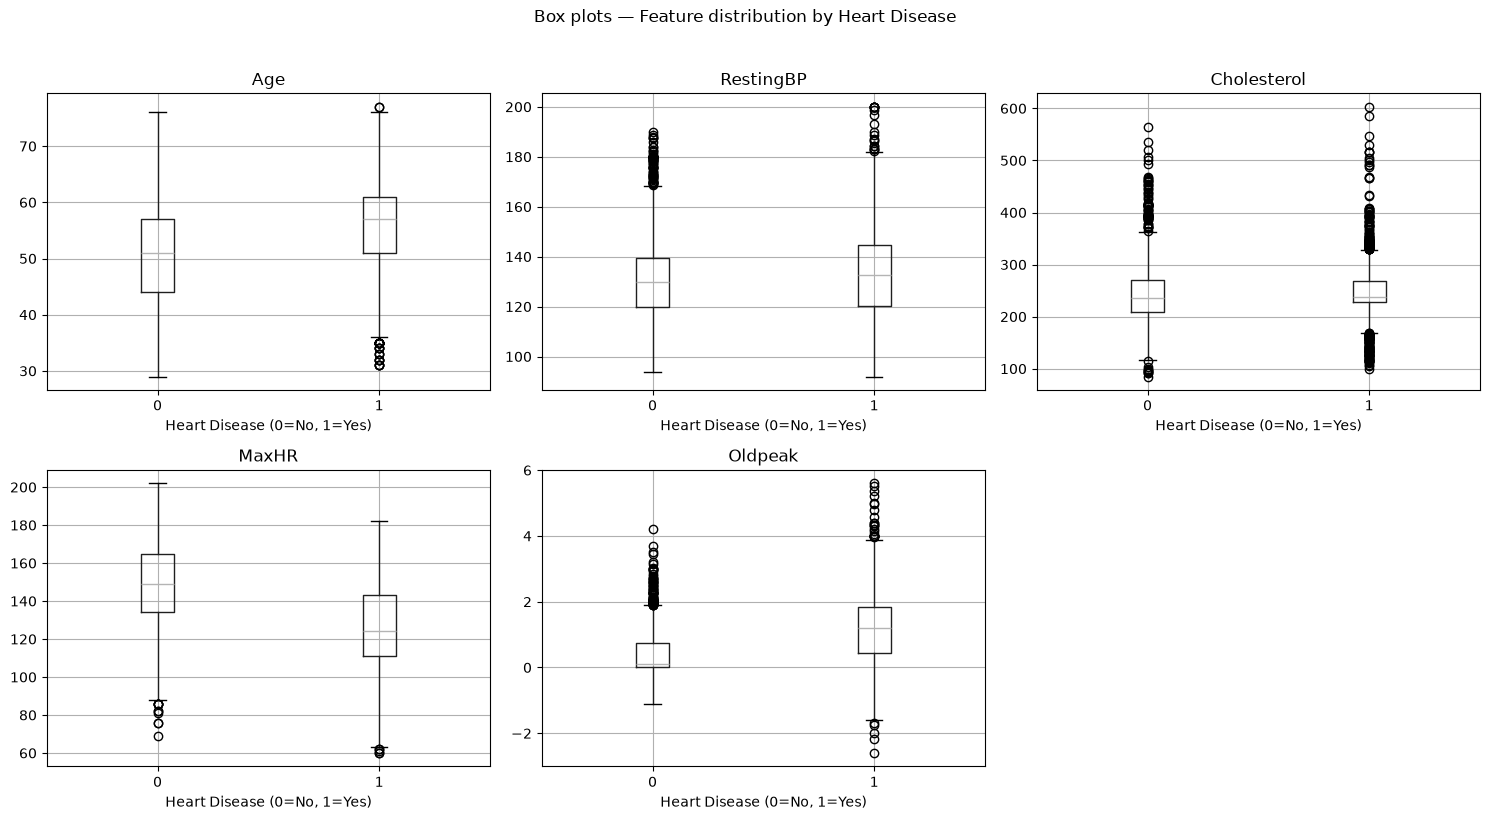

In [17]:
# Box plots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i, col in enumerate(num_features):
    ax = axes[i//3][i%3]
    df.boxplot(column=col, by='HeartDisease', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Heart Disease (0=No, 1=Yes)')

axes[1][2].set_visible(False)
plt.suptitle('Box plots — Feature distribution by Heart Disease', y=1.02)
plt.tight_layout()
plt.show()